In [1]:
import random
import networkx as nx
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
path_to_networks = Path('social_networks')

## Facebook Dataset
This dataset consists of 'circles' (or 'friends lists') from Facebook. Facebook data was collected from survey participants using this Facebook app. The dataset includes node features (profiles), circles, and ego networks.

| Name         | Type       | Nodes | Edges  | Description                               |
|--------------|------------|-------|--------|-------------------------------------------|
| ego-Facebook | Undirected | 4,039 | 88,234 | Social circles from Facebook (anonymized) |

In [3]:
fb_graph = nx.read_edgelist(
    'social_networks/facebook.txt',
    nodetype=int,
)

for u, v in fb_graph.edges():
    fb_graph[u][v]['weight'] = round(random.random(), 2)

print(f'Graph info: {fb_graph}')
print(f'Average clustering: {nx.average_clustering(fb_graph)}')
print(f'Global clustering: {nx.transitivity(fb_graph)}')

Graph info: Graph with 4039 nodes and 88234 edges
Average clustering: 0.6055467186200862
Global clustering: 0.5191742775433075


In [4]:
from src import GraphGenerator


class FacebookGraph(GraphGenerator):
    def generate_graph(self):
        """
        Generates a WattsStrogatz Graph
        """
        self.graph = nx.read_edgelist(
            'social_networks/facebook.txt',
            nodetype=int,
        )

        self.node_costs = {
            node: random.uniform(0.1, 25.0)
            for node in self.graph.nodes()
        }

        for node, cost in self.node_costs.items():
            self.graph.nodes[node]['node_costs'] = cost

        self.communities = self.louvain_communities()

        for i, community in enumerate(self.communities):
            for node in community:
                self.graph.nodes[node]['community'] = i


generator = FacebookGraph()
generator.generate_graph()
generator.serialise(path_to_networks, 'facebook')

Graph serialised to social_networks\facebook.pkl


## Twitter Dataset
This dataset consists of 'circles' (or 'lists') from Twitter. Twitter data was crawled from public sources. The dataset includes node features (profiles), circles, and ego networks.
| Name         | Type       | Nodes | Edges  | Description                               |
|--------------|------------|-------|--------|-------------------------------------------|
| ego-Twitter | Directed | 81,306 | 1,768,149 | Social circles from Twitter |

In [5]:
tw_graph = nx.read_edgelist(
    'social_networks/twitter.txt',
    nodetype=int,
    create_using=nx.DiGraph(),
)

for u, v in tw_graph.edges():
    tw_graph[u][v]['weight'] = round(random.random(), 2)

print(f'Graph info: {tw_graph}')
print(f'Average clustering: {nx.average_clustering(tw_graph)}')
print(f'Global clustering: {nx.transitivity(tw_graph)}')

Graph info: DiGraph with 81306 nodes and 1768149 edges
Average clustering: 0.40189526780760837
Global clustering: 0.21751023226741378


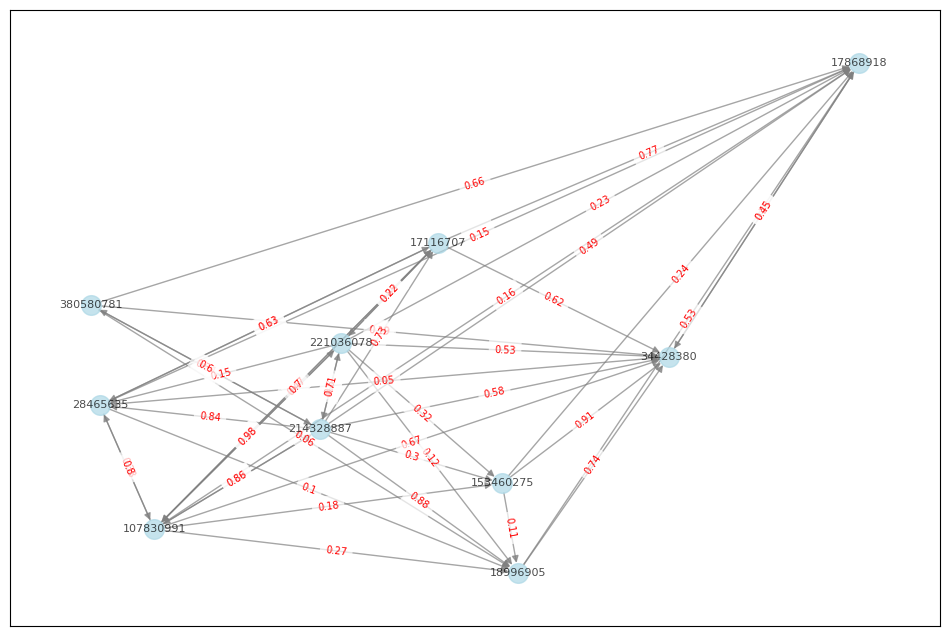

In [6]:
sample_nodes = list(tw_graph.nodes())[:10]
subgraph = tw_graph.subgraph(sample_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(
    subgraph,
    k=0.15,
    iterations=50,
)

nx.draw_networkx(
    subgraph,
    pos,
    node_size=200,
    with_labels=True,
    font_size=8,
    node_color='lightblue',
    edge_color='gray',
    alpha=0.7,
)

if nx.get_edge_attributes(subgraph, 'weight'):
    edge_labels = nx.get_edge_attributes(subgraph, 'weight')
    nx.draw_networkx_edge_labels(
        subgraph,
        pos,
        edge_labels=edge_labels,
        font_size=7,
        font_color="red",
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7),
    )

plt.show()